# Closed-region window mean relative RPKM plots

Create window summaries and relative-repair profiles for H3K9me3 and H3K27me3 regions.

In [1]:
from pathlib import Path
import math
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path('/cta/users/guneyn23/relative_repair/closed_regions')
REGIONS = ['H3K9me3', 'H3K27me3']
DAMAGE_TYPES = ['CPD', '64']
TIMEPOINTS = ['15m', '30m', '1h', '4h', '8h']
WINDOW_COUNT = 400
WINDOW_SIZE_KB = 0.05

COLORS = {
    '15m': '#0072B2',
    '30m': '#E69F00',
    '1h': '#009E73',
    '4h': '#D55E00',
    '8h': '#CC79A7',
}

YLIMS = {
    'real_mean': (0.30, 0.80),
    'sim_mean': (0.45, 0.70),
    'real_sim_ratio': (0.65, 1.25),
}

In [2]:
def make_summary(real_file, sim_file):
    real_sum = [0.0] * (WINDOW_COUNT + 1)
    real_count = [0] * (WINDOW_COUNT + 1)
    sim_sum = [0.0] * (WINDOW_COUNT + 1)
    sim_count = [0] * (WINDOW_COUNT + 1)

    for input_file, sums, counts in [
        (real_file, real_sum, real_count),
        (sim_file, sim_sum, sim_count),
    ]:
        with input_file.open() as infile:
            for line in infile:
                values = line.rstrip('\n').split('\t')
                if len(values) < 6 or values[5] == '':
                    continue
                window = int(values[3].split('_')[-1])
                relative_rpkm = float(values[5])
                if not math.isfinite(relative_rpkm):
                    continue
                sums[window] += relative_rpkm
                counts[window] += 1

    rows = []
    for window in range(1, WINDOW_COUNT + 1):
        real_mean = real_sum[window] / real_count[window] if real_count[window] else float('nan')
        sim_mean = sim_sum[window] / sim_count[window] if sim_count[window] else float('nan')
        real_sim_ratio = (
            real_mean / sim_mean
            if math.isfinite(sim_mean) and sim_mean != 0
            else float('nan')
        )
        rows.append({
            'window': window,
            'real_mean': real_mean,
            'sim_mean': sim_mean,
            'real_sim_ratio': real_sim_ratio,
        })

    return pd.DataFrame(rows)

## Calculate and save window summaries

In [3]:
summaries = {}

for region in REGIONS:
    region_dir = BASE_DIR / region
    summary_dir = region_dir / 'window_summaries'
    summary_dir.mkdir(parents=True, exist_ok=True)
    summaries[region] = {}

    for damage_type in DAMAGE_TYPES:
        summaries[region][damage_type] = {}

        for timepoint in TIMEPOINTS:
            real_file = region_dir / f'{damage_type}_{timepoint}_real_relative_rpkm.tsv'
            sim_file = region_dir / f'{damage_type}_{timepoint}_sim_relative_rpkm.tsv'
            summary = make_summary(real_file, sim_file)
            summaries[region][damage_type][timepoint] = summary

            summary_file = summary_dir / f'{damage_type}_{timepoint}_window_summary.tsv'
            summary.to_csv(summary_file, sep='\t', index=False)
            print(f'Written: {summary_file}')

Written: /cta/users/guneyn23/relative_repair/closed_regions/H3K9me3/window_summaries/CPD_15m_window_summary.tsv
Written: /cta/users/guneyn23/relative_repair/closed_regions/H3K9me3/window_summaries/CPD_30m_window_summary.tsv
Written: /cta/users/guneyn23/relative_repair/closed_regions/H3K9me3/window_summaries/CPD_1h_window_summary.tsv
Written: /cta/users/guneyn23/relative_repair/closed_regions/H3K9me3/window_summaries/CPD_4h_window_summary.tsv
Written: /cta/users/guneyn23/relative_repair/closed_regions/H3K9me3/window_summaries/CPD_8h_window_summary.tsv
Written: /cta/users/guneyn23/relative_repair/closed_regions/H3K9me3/window_summaries/64_15m_window_summary.tsv
Written: /cta/users/guneyn23/relative_repair/closed_regions/H3K9me3/window_summaries/64_30m_window_summary.tsv
Written: /cta/users/guneyn23/relative_repair/closed_regions/H3K9me3/window_summaries/64_1h_window_summary.tsv
Written: /cta/users/guneyn23/relative_repair/closed_regions/H3K9me3/window_summaries/64_4h_window_summary.tsv
W

In [5]:
# Use this cell instead of the calculation cell when summary TSVs already exist.
summaries = {}

for region in REGIONS:
    summary_dir = BASE_DIR / region / 'window_summaries'
    summaries[region] = {}

    for damage_type in DAMAGE_TYPES:
        summaries[region][damage_type] = {}

        for timepoint in TIMEPOINTS:
            summary_file = summary_dir / f'{damage_type}_{timepoint}_window_summary.tsv'
            summaries[region][damage_type][timepoint] = pd.read_csv(
                summary_file, sep='\t'
            )

print('Loaded saved window-summary tables; no recalculation was performed.')

Loaded saved window-summary tables; no recalculation was performed.


In [6]:
def plot_profiles(region, damage_type, value_column, ylabel, title_text, output_suffix):
    plt.figure(figsize=(12, 6.5))

    for timepoint in TIMEPOINTS:
        table = summaries[region][damage_type][timepoint]
        distance_kb = (table['window'] - (WINDOW_COUNT + 1) / 2) * WINDOW_SIZE_KB
        plt.plot(
            distance_kb,
            table[value_column],
            color=COLORS[timepoint],
            linewidth=2.2,
            label=timepoint,
        )

    plt.axvline(x=0, color='gray', linestyle='--', linewidth=1.5, label='Peak center')
    plt.xlim(-10, 10)
    plt.ylim(*YLIMS[value_column])
    plt.xticks([-10, -5, 0, 5, 10])
    plt.xlabel(f'Distance from {region} peak center (kb)', fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.title(
        f'{damage_type} {title_text} Around {region} Peak Centers',
        fontsize=14,
        fontweight='bold',
    )
    plt.grid(axis='y', linestyle=':', alpha=0.35)
    plt.legend(title='Time point', frameon=False, ncol=3)
    plt.tight_layout()

    plot_dir = BASE_DIR / region / 'plots'
    plot_dir.mkdir(parents=True, exist_ok=True)
    output_file = plot_dir / f'{damage_type}_window_mean_{output_suffix}.png'
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Written: {output_file}')

## Create plots

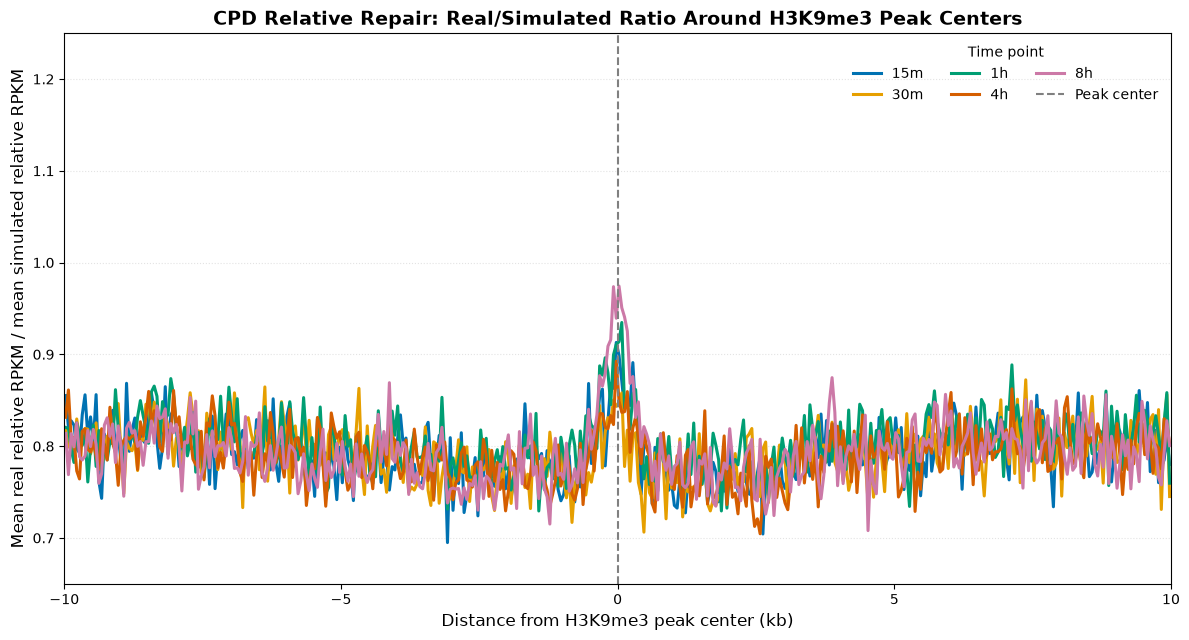

Written: /cta/users/guneyn23/relative_repair/closed_regions/H3K9me3/plots/CPD_window_mean_real_sim.png


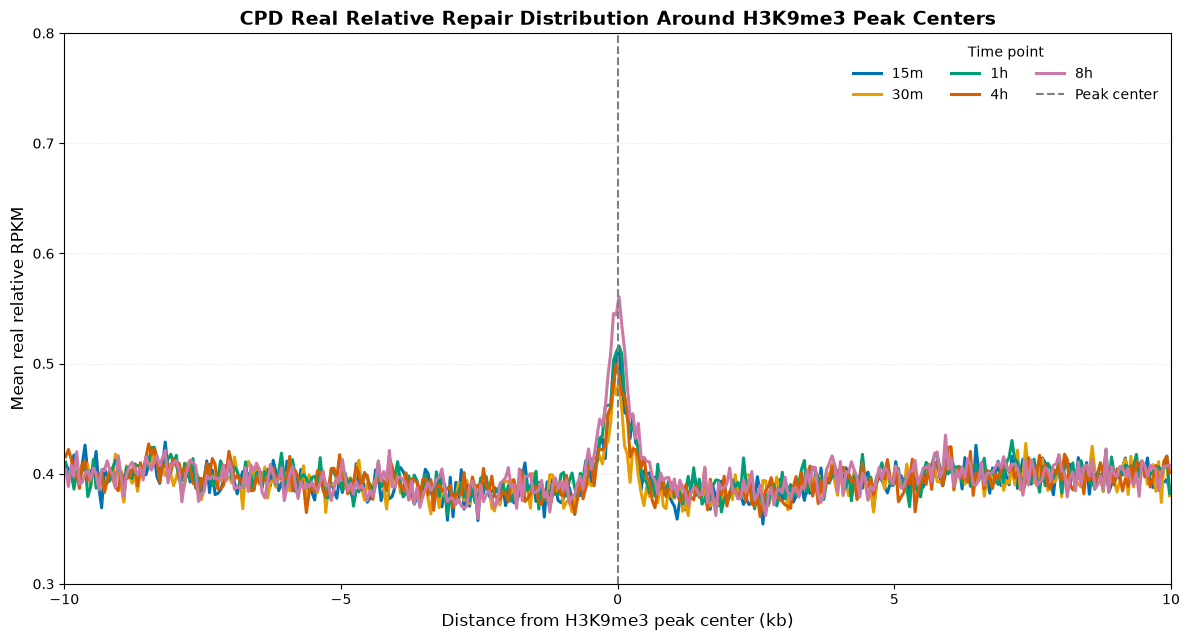

Written: /cta/users/guneyn23/relative_repair/closed_regions/H3K9me3/plots/CPD_window_mean_real.png


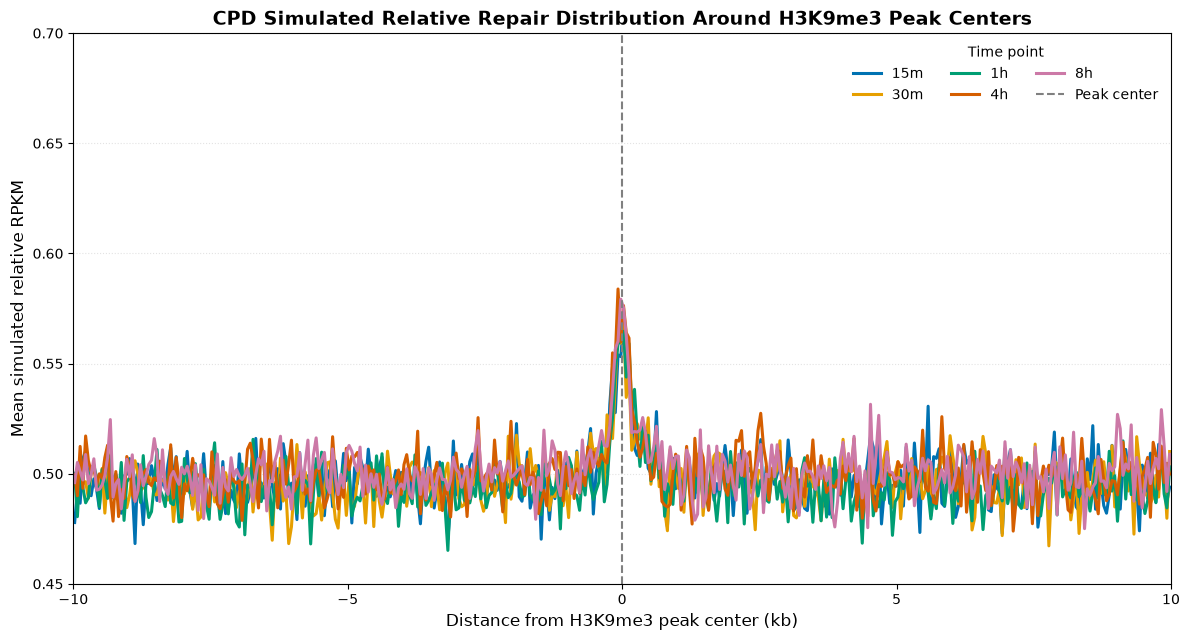

Written: /cta/users/guneyn23/relative_repair/closed_regions/H3K9me3/plots/CPD_window_mean_sim.png


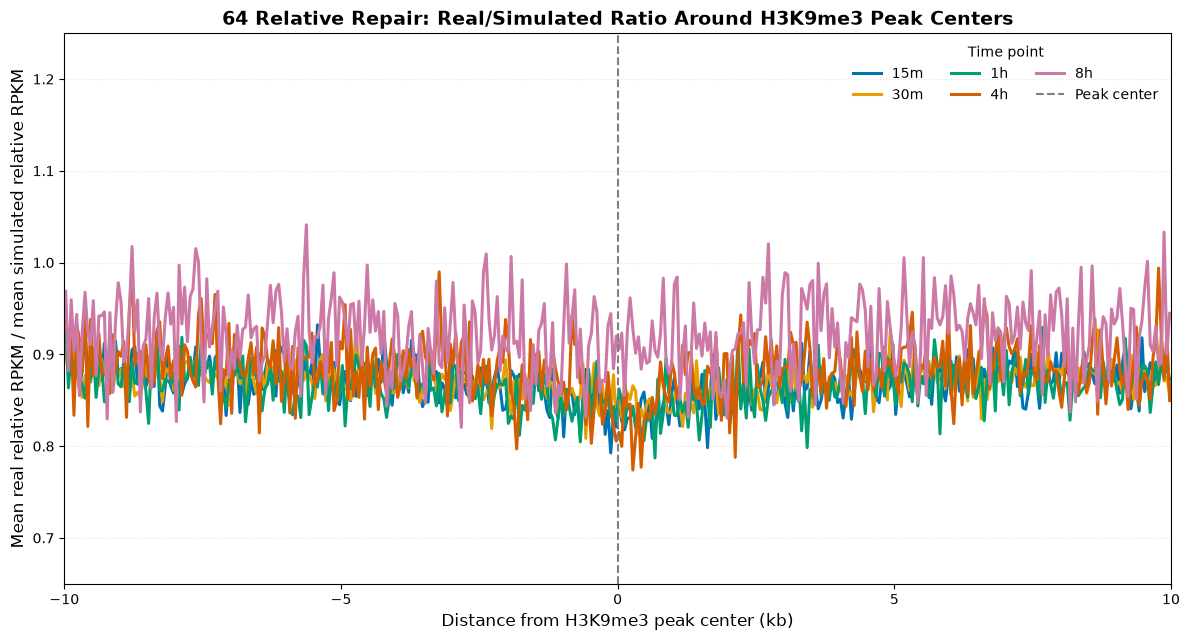

Written: /cta/users/guneyn23/relative_repair/closed_regions/H3K9me3/plots/64_window_mean_real_sim.png


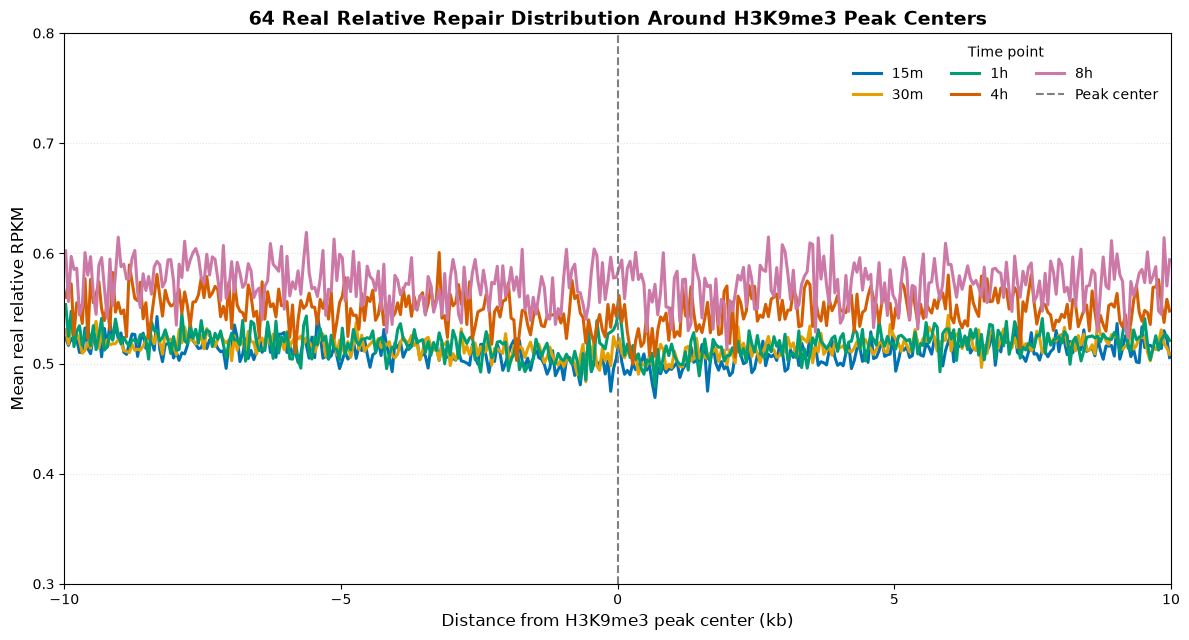

Written: /cta/users/guneyn23/relative_repair/closed_regions/H3K9me3/plots/64_window_mean_real.png


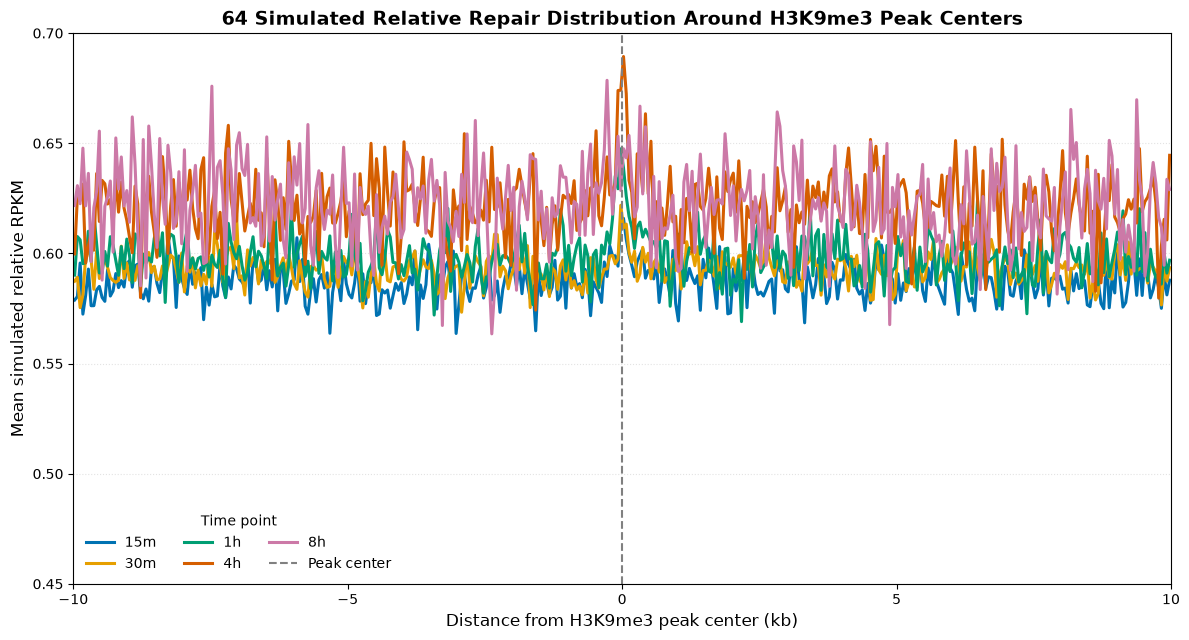

Written: /cta/users/guneyn23/relative_repair/closed_regions/H3K9me3/plots/64_window_mean_sim.png


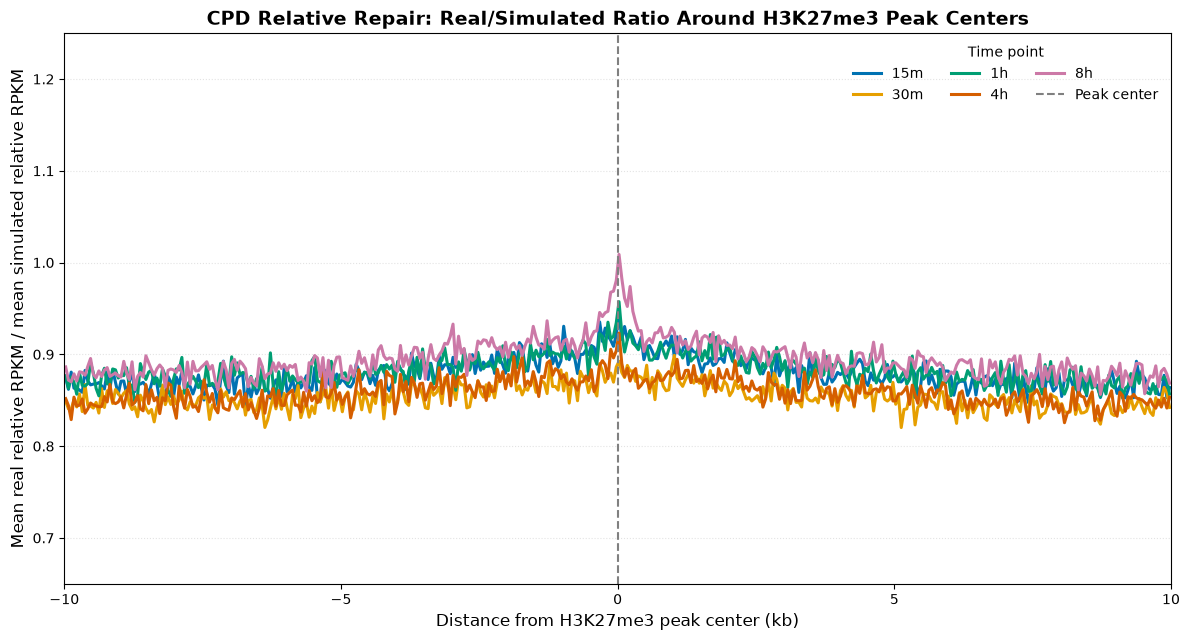

Written: /cta/users/guneyn23/relative_repair/closed_regions/H3K27me3/plots/CPD_window_mean_real_sim.png


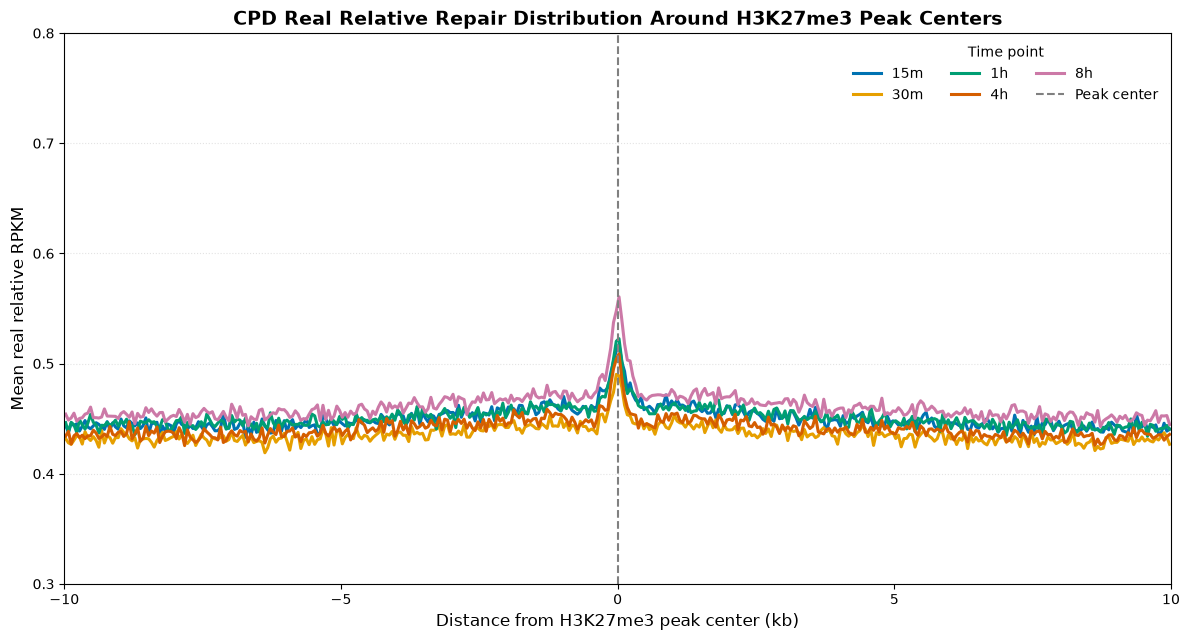

Written: /cta/users/guneyn23/relative_repair/closed_regions/H3K27me3/plots/CPD_window_mean_real.png


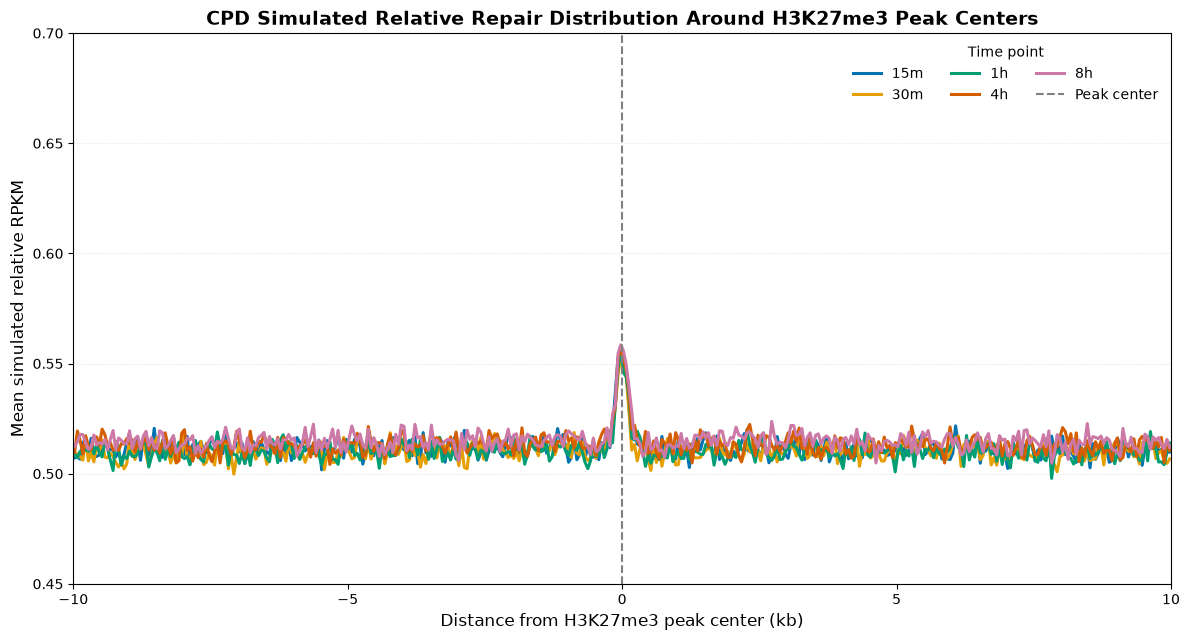

Written: /cta/users/guneyn23/relative_repair/closed_regions/H3K27me3/plots/CPD_window_mean_sim.png


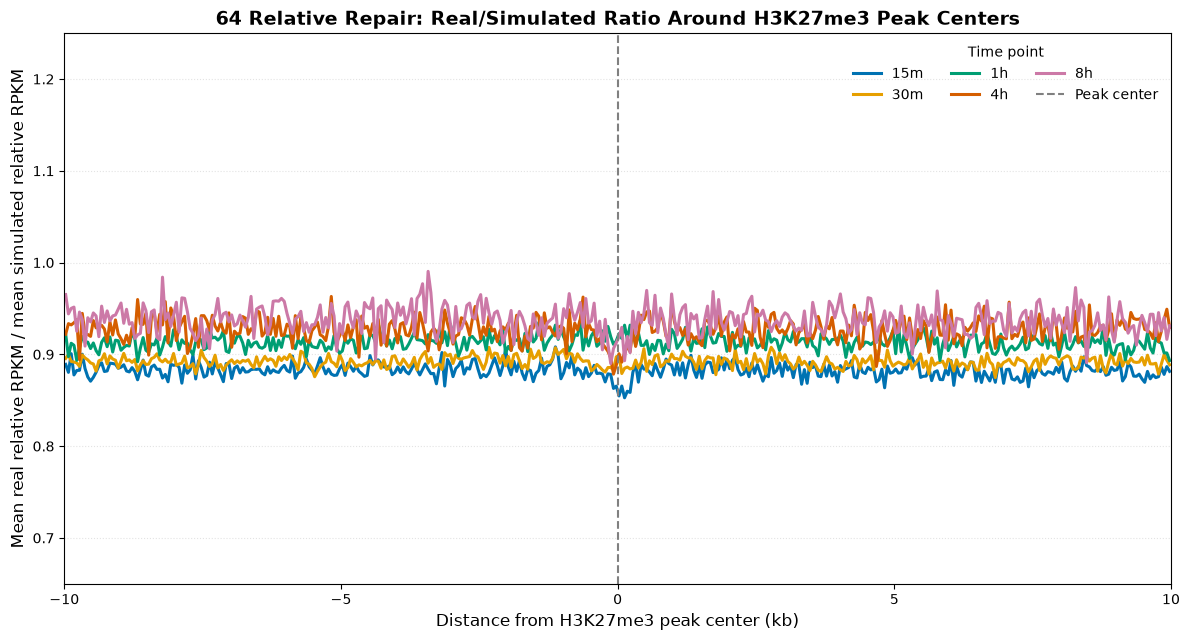

Written: /cta/users/guneyn23/relative_repair/closed_regions/H3K27me3/plots/64_window_mean_real_sim.png


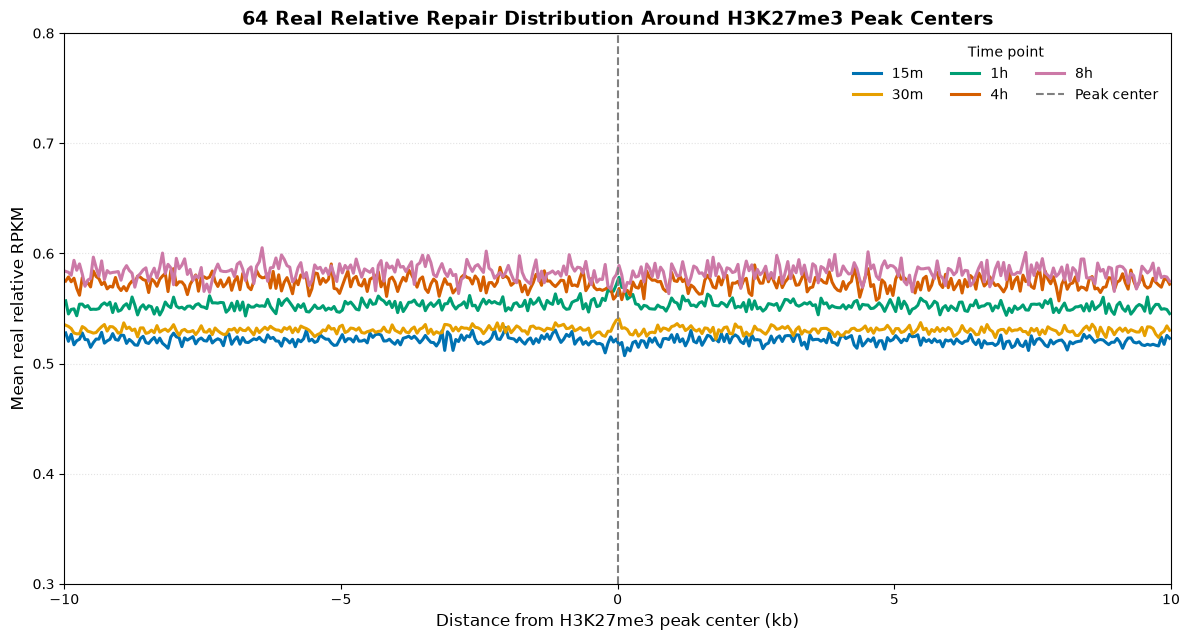

Written: /cta/users/guneyn23/relative_repair/closed_regions/H3K27me3/plots/64_window_mean_real.png


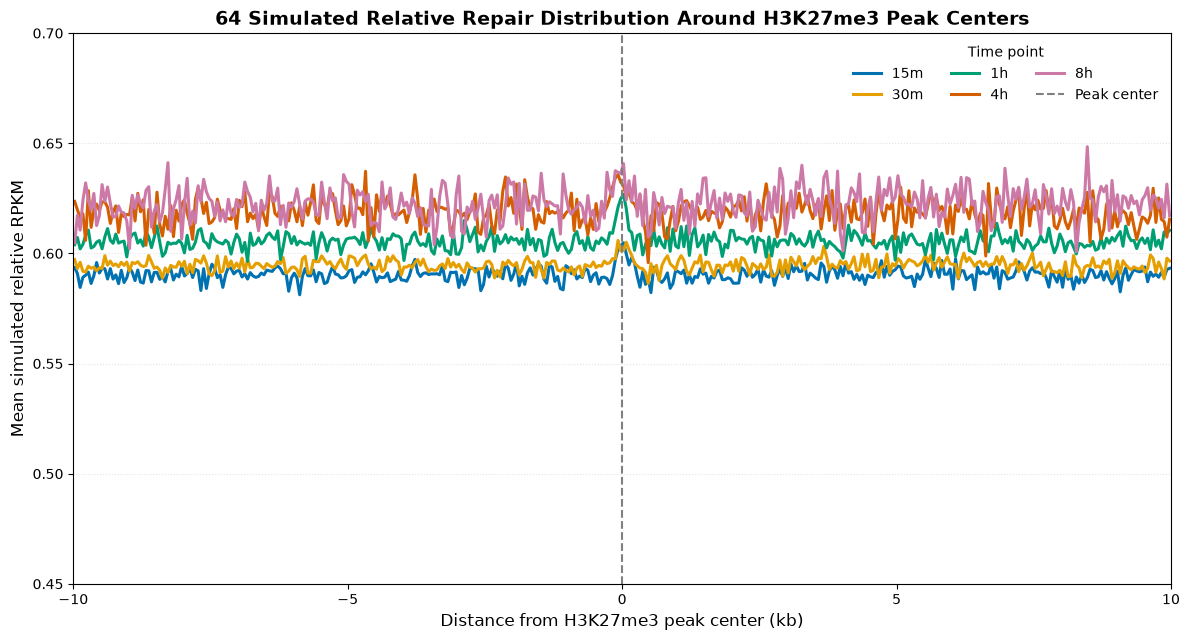

Written: /cta/users/guneyn23/relative_repair/closed_regions/H3K27me3/plots/64_window_mean_sim.png


In [7]:
PLOT_TYPES = [
    (
        'real_sim_ratio',
        'Mean real relative RPKM / mean simulated relative RPKM',
        'Relative Repair: Real/Simulated Ratio',
        'real_sim',
    ),
    (
        'real_mean',
        'Mean real relative RPKM',
        'Real Relative Repair Distribution',
        'real',
    ),
    (
        'sim_mean',
        'Mean simulated relative RPKM',
        'Simulated Relative Repair Distribution',
        'sim',
    ),
]

for region in REGIONS:
    for damage_type in DAMAGE_TYPES:
        for value_column, ylabel, title_text, output_suffix in PLOT_TYPES:
            plot_profiles(
                region, damage_type, value_column, ylabel, title_text, output_suffix
            )